In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, LSTM, Dropout, Conv1D, MaxPooling1D, Flatten

from tensorflow import keras
from tensorflow.keras.models import Sequential
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

from wordcloud import WordCloud

In [2]:
data = pd.read_excel('D:/Kerjaan/Project P68800125 (Model Indobert with CNN-LTSM)/FIX data_label 3 kls.xlsx')

In [3]:
data.head()

,Unnamed: 0,created_at,full_text,username,clean,normal,token,stemmed,teks,label
0,1,2022-01-27 12:29:56+00:00,"gpp company lokal asal WFA, mungkin bukan peng...",xyberya,gpp company lokal asal wfa mungkin bukan penge...,tidak apa apa company lokal asal wfa mungkin b...,"['tidak', 'apa', 'apa', 'company', 'lokal', 'a...","['tidak', 'apa', 'apa', 'company', 'lokal', 'a...","[tidak, apa, apa, company, lokal, asal, wfa, m...",negative
1,2,2022-01-27 11:33:49+00:00,@arifsyh86 @pipis @MrsEuscha @tbputera Sorry b...,ninanenen,sorry baru liat notif tidak harus di jakarta k...,sorry baru liat notif tidak harus di jakarta k...,"['sorry', 'baru', 'liat', 'notif', 'tidak', 'h...","['sorry', 'baru', 'liat', 'notif', 'tidak', 'h...","[sorry, baru, liat, notif, tidak, harus, di, j...",negative
2,3,2022-01-27 09:40:40+00:00,Yay nambah opsi baru wfa spot di cibi ????????...,mirzarm,yay nambah opsi baru wfa spot di cibi,yay nambah opsi baru wfa spot di cibi,"['yay', 'nambah', 'opsi', 'baru', 'wfa', 'spot...","['yay', 'nambah', 'opsi', 'baru', 'wfa', 'spot...","[yay, nambah, opsi, baru, wfa, spot, di, cibi]",neutral
3,4,2022-01-27 04:39:49+00:00,Jadi pelaksana proyek susah kalo wfa. Apalagi ...,segedegabun,jadi pelaksana proyek susah kalo wfa apalagi a...,jadi pelaksana proyek susah kalau wfa apalagi ...,"['jadi', 'pelaksana', 'proyek', 'susah', 'kala...","['jadi', 'laksana', 'proyek', 'susah', 'kalau'...","[jadi, laksana, proyek, susah, kalau, wfa, apa...",negative
4,5,2022-01-27 00:30:58+00:00,tujuan karir sekarang fokusnya lebih ke work l...,favophs,tujuan karir sekarang fokusnya lebih ke work l...,tujuan karir sekarang fokusnya lebih ke work l...,"['tujuan', 'karir', 'sekarang', 'fokusnya', 'l...","['tuju', 'karir', 'sekarang', 'fokus', 'lebih'...","[tuju, karir, sekarang, fokus, lebih, ke, work...",positive


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13649 entries, 0 to 13648
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  13649 non-null  int64 
 1   created_at  13649 non-null  object
 2   full_text   13649 non-null  object
 3   username    13649 non-null  object
 4   clean       13649 non-null  object
 5   normal      13649 non-null  object
 6   token       13649 non-null  object
 7   stemmed     13649 non-null  object
 8   teks        13649 non-null  object
 9   label       13649 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.0+ MB


In [6]:
data['label'].value_counts()

label
neutral     7472
negative    3836
positive    2341
Name: count, dtype: int64

In [7]:
data.isnull().sum()

Unnamed: 0    0
created_at    0
full_text     0
username      0
clean         0
normal        0
token         0
stemmed       0
teks          0
label         0
dtype: int64

In [8]:
data.duplicated().sum()

0

In [ ]:
data_positif=data[data['Sentimen']=="positif"]
all_words_lem = ' '.join([word for word in data_positif['teks']])
%matplotlib inline
wordcloud = WordCloud(background_color='white', width=800, height=500, random_state=21, max_font_size=130).generate(all_words_lem)
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Wordcloud Sentimen Positif', fontsize=20)
plt.axis('off');

In [ ]:
data_netral=data[data['Sentimen']=="netral"]
all_words_lem = ' '.join([word for word in data_netral['teks']])
%matplotlib inline
wordcloud = WordCloud(background_color='white', width=800, height=500, random_state=21, max_font_size=130).generate(all_words_lem)
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Wordcloud Sentimen Netral', fontsize=20)
plt.axis('off');

In [ ]:
data_negatif=data[data['Sentimen']=="negatif"]
all_words_lem = ' '.join([word for word in data_negatif['teks']])
%matplotlib inline
wordcloud = WordCloud(background_color='white', width=800, height=500, random_state=21, max_font_size=130).generate(all_words_lem)
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Wordcloud Sentimen Negatif', fontsize=20)
plt.axis('off');

Data Preparation

In [9]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['teks']).toarray()
y = data['label']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, random_state=42, stratify=y)

CNN-LTSM Model

In [11]:
# Define CNN-LSTM model
def create_model(optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], 1)))  # Input layer

    # CNN Layers
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    # LSTM Layers
    model.add(LSTM(32, activation='tanh', return_sequences=True))
    model.add(Dropout(0.2))

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(3, activation='sigmoid'))

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [12]:
# Wrap the model for GridSearch
model = KerasClassifier(model=create_model, verbose=2)

In [13]:
# Define parameter grid
param_grid = {
    'epochs': [10,30],
    'batch_size': [64, 128]
}

In [14]:
# GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5,n_jobs=-1, verbose=2)
grid_result = grid.fit(X_train, y_train)

# Print best parameters and accuracy
print("Best parameters found: ", grid.best_params_)
print("Best accuracy: ", grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Epoch 1/10
171/171 - 175s - 1s/step - accuracy: 0.5786 - loss: 0.9346
Epoch 2/10
171/171 - 175s - 1s/step - accuracy: 0.6695 - loss: 0.7624
Epoch 3/10
171/171 - 174s - 1s/step - accuracy: 0.7312 - loss: 0.6424
Epoch 4/10
171/171 - 175s - 1s/step - accuracy: 0.7706 - loss: 0.5528
Epoch 5/10
171/171 - 173s - 1s/step - accuracy: 0.8101 - loss: 0.4658
Epoch 6/10
171/171 - 173s - 1s/step - accuracy: 0.8390 - loss: 0.3939
Epoch 7/10
171/171 - 173s - 1s/step - accuracy: 0.8614 - loss: 0.3329
Epoch 8/10
171/171 - 173s - 1s/step - accuracy: 0.8821 - loss: 0.2804
Epoch 9/10
171/171 - 173s - 1s/step - accuracy: 0.8951 - loss: 0.2474
Epoch 10/10
171/171 - 173s - 1s/step - accuracy: 0.9089 - loss: 0.2206
Best parameters found:  {'batch_size': 64, 'epochs': 10}
Best accuracy:  0.7178312182549471


In [16]:
# Gunakan model terbaik dari GridSearchCV
best_model = grid.best_estimator_

In [19]:
# Evaluate the model on the test set
y_pred = best_model.predict(X_test)

43/43 - 8s - 181ms/step


In [20]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

    negative       0.62      0.58      0.60       767
     neutral       0.77      0.82      0.79      1495
    positive       0.61      0.56      0.58       468

    accuracy                           0.71      2730
   macro avg       0.67      0.65      0.66      2730
weighted avg       0.70      0.71      0.70      2730



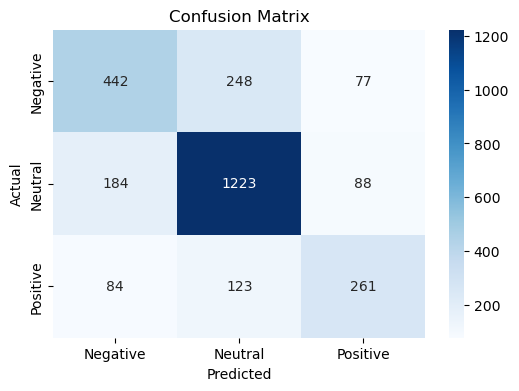

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()